In [236]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [237]:
df = pd.read_csv("trainExtended_morgan1812.csv")
df = df.dropna()



y = np.array(df["Tm"])
X = np.array(df.drop(["Tm", "SMILES"], axis = 1))

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.3)

In [ ]:
w = np.ones(len(y_train))
w[y_train >= 400] = 3.0   # ggf. 2.0–5.0 testen

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
y_tr_t = pt.fit_transform(y_train.reshape(-1,1)).ravel()




model = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:absoluteerror",
    tree_method="hist",
    random_state=22
)

model.fit(X, y, verbose=False, sample_weight=w) 
pred_test = model.predict(X_test)

#Mit Powertransformer

# model.fit(X_train, y_tr_t, sample_weight=w)
# pred = pt.inverse_transform(
#     model.predict(X_test).reshape(-1,1)
# ).ravel()


In [301]:
testSet = pd.read_csv("melting-point-data/morganfeatures_test.csv")
testSetready = testSet.drop(["Unnamed: 0", "id", "SMILES"], axis=1)

y_test_pred = model.predict(np.array(testSetready))
y_test_pred = np.array(y_test_pred)
y_testset_merge = pd.DataFrame(y_test_pred, columns=["Tm_pred"])

testSet["Tm_pred"] = y_test_pred

testSet = testSet.drop(["Unnamed: 0"], axis = 1)

model_2_pred = testSet[testSet["Tm_pred"] > 330]

model_2_pred.to_csv("model_2_testset.csv", index = False)

In [256]:
mae = np.mean(np.abs(pred_test - y_test))

mae



np.float64(28.793550733577568)

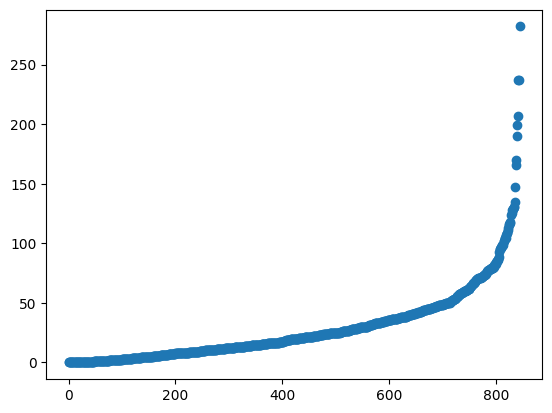

In [240]:
import matplotlib.pyplot as plt
X_test.shape
i = 845
x_axis = np.arange(0,845,1)
plt.scatter(x_axis[:i], sorted_dev[:i])
# plt.scatter(x_axis[:i], y_test[:i])

sorted_dev = np.sort(np.abs(pred_test-y_test))


In [257]:
np.mean(sorted_dev[:400])

np.float64(7.4876032836914055)

In [242]:
test = pd.read_csv("melting-point-data/morganfeatures_test.csv")

X_m_test = np.array(test.drop(["Unnamed: 0", "id", "SMILES"], axis = 1))

pred_m_test = model.predict(X_m_test)



In [243]:
submission = pd.DataFrame({"id": test["id"], "Tm": pred_m_test })

In [244]:
# submission.to_csv("submission1812.csv", index=False)

In [245]:
df

,SMILES,Tm,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,FC1=C(F)C(F)(F)C1(F)F,213.15,11.537037,11.537037,2.668981,-4.947338,0.479530,28.200000,162.032,162.032,...,0,0,0,0,0,0,0,0,1,0
1,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,3.470111,3.470111,1.207271,1.207271,0.446879,11.529412,217.271,206.183,...,0,0,0,0,1,1,1,0,1,0
2,CCN1C(C)=Nc2ccccc12,324.15,4.446898,4.446898,0.992407,0.992407,0.625839,10.833333,160.220,148.124,...,0,1,0,1,1,1,1,0,1,0
3,CC#CC(=O)O,351.15,9.425694,9.425694,1.071759,-1.071759,0.422302,5.500000,84.074,80.042,...,1,0,1,1,0,0,0,1,0,0
4,CCCCC(S)C,126.15,4.232083,4.232083,0.597176,0.597176,0.540734,14.142857,118.245,104.133,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2821,CC(C)NCC(COC1=CC=CC=C1CC=C)O,380.15,9.772509,9.772509,0.299480,-0.496123,0.693681,12.444444,249.354,226.170,...,1,1,1,1,1,1,1,1,1,0
2822,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,445.15,4.317778,4.317778,0.664259,0.664259,0.703380,10.000000,210.285,192.141,...,0,1,0,1,1,1,1,0,1,0
2823,C1C2CC3CC1CC(C2)(C3)N,433.15,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,134.117,...,0,1,0,0,1,0,1,0,1,0
2824,CC[N+](CC)(CCNC(=O)C(=O)NCC[N+](CC)(CC)CC1=CC=...,469.15,12.474516,12.474516,0.425409,-0.587731,0.272662,11.833333,537.576,495.240,...,0,1,1,1,1,1,1,1,1,0


In [246]:
basic = pd.read_csv("melting-point-data/train.csv")
basic

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,707,ClCCBr,256.45,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2658,1573,N#CC(Cl)(Cl)Cl,231.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2659,1634,Cc1ccc2c(C)cccc2c1,256.25,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2660,3022,CCC(=O)c1ccc2ccccc2c1,333.15,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [247]:
analysis_df = df.copy()
df.columns


Index(['SMILES', 'Tm', 'MaxAbsEStateIndex', 'MaxEStateIndex',
       'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt',
       'HeavyAtomMolWt',
       ...
       'MACCS_157', 'MACCS_158', 'MACCS_159', 'MACCS_160', 'MACCS_161',
       'MACCS_162', 'MACCS_163', 'MACCS_164', 'MACCS_165', 'MACCS_166'],
      dtype='object', length=2434)

In [248]:
df

,SMILES,Tm,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,FC1=C(F)C(F)(F)C1(F)F,213.15,11.537037,11.537037,2.668981,-4.947338,0.479530,28.200000,162.032,162.032,...,0,0,0,0,0,0,0,0,1,0
1,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,3.470111,3.470111,1.207271,1.207271,0.446879,11.529412,217.271,206.183,...,0,0,0,0,1,1,1,0,1,0
2,CCN1C(C)=Nc2ccccc12,324.15,4.446898,4.446898,0.992407,0.992407,0.625839,10.833333,160.220,148.124,...,0,1,0,1,1,1,1,0,1,0
3,CC#CC(=O)O,351.15,9.425694,9.425694,1.071759,-1.071759,0.422302,5.500000,84.074,80.042,...,1,0,1,1,0,0,0,1,0,0
4,CCCCC(S)C,126.15,4.232083,4.232083,0.597176,0.597176,0.540734,14.142857,118.245,104.133,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2821,CC(C)NCC(COC1=CC=CC=C1CC=C)O,380.15,9.772509,9.772509,0.299480,-0.496123,0.693681,12.444444,249.354,226.170,...,1,1,1,1,1,1,1,1,1,0
2822,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,445.15,4.317778,4.317778,0.664259,0.664259,0.703380,10.000000,210.285,192.141,...,0,1,0,1,1,1,1,0,1,0
2823,C1C2CC3CC1CC(C2)(C3)N,433.15,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,134.117,...,0,1,0,0,1,0,1,0,1,0
2824,CC[N+](CC)(CCNC(=O)C(=O)NCC[N+](CC)(CC)CC1=CC=...,469.15,12.474516,12.474516,0.425409,-0.587731,0.272662,11.833333,537.576,495.240,...,0,1,1,1,1,1,1,1,1,0


In [249]:
y1 = np.array(df["Tm"])
X1 = np.array(df)

X1_train, X1_test, y1_train, y1_test = train_test_split(X1,y1, test_size=0.3, random_state=42)

In [250]:
X1_test[0:4]

array([['Clc1ccc(Cl)cc1', 325.85, 5.553024691358024, ..., 0, 1, 0],
       ['C#CC(C)C', 183.45, 4.921296296296296, ..., 0, 0, 0],
       ['Nc1cccc(c1)Oc2ccccc2', 310.15, 5.632249937011842, ..., 1, 1, 0],
       ['CCCCCC1=CCCC1', 190.15, 2.440138888888889, ..., 0, 1, 0]],
      shape=(4, 2434), dtype=object)

In [251]:
analysis_df = pd.DataFrame(X1_test, columns = df.columns)
analysis_df["Tm_pred"] = pred_test

In [252]:
cols = list(analysis_df.columns)

# Tm und Tm_pred nebeneinander bringen
cols.remove("Tm_pred")
tm_index = cols.index("Tm")
cols.insert(tm_index + 1, "Tm_pred")

analysis_df = analysis_df[cols]


analysis_df

,SMILES,Tm,Tm_pred,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,Clc1ccc(Cl)cc1,325.85,285.958191,5.553025,5.553025,0.717037,0.717037,0.528586,9.25,147.004,...,0,0,0,0,0,1,1,0,1,0
1,C#CC(C)C,183.45,163.205383,4.921296,4.921296,0.412037,0.412037,0.374957,7.6,68.119,...,0,0,0,1,0,0,0,0,0,0
2,Nc1cccc(c1)Oc2ccccc2,310.15,348.365112,5.63225,5.63225,0.706881,0.706881,0.729582,9.714286,185.226,...,1,1,0,0,1,1,1,1,1,0
3,CCCCCC1=CCCC1,190.15,213.571533,2.440139,2.440139,1.348669,1.348669,0.410427,17.5,138.254,...,0,0,0,1,0,0,0,0,1,0
4,CNCC(=O)O,481.15,481.161377,9.536806,9.536806,0.041667,-0.821759,0.469563,8.166667,89.094,...,1,1,1,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,COCCOC(=O)c1ccccc1C(=O)OCCOC,228.15,286.365631,11.864498,11.864498,0.127371,-0.582091,0.528356,10.1,282.292,...,1,0,1,1,0,1,1,1,1,0
841,O=C(C)C,178.35,194.201950,9.444444,9.444444,0.166667,0.166667,0.398237,6.5,58.08,...,0,0,0,1,0,0,0,1,0,0
842,CCc1ccc(CC)cc1,230.32,214.569794,2.207176,2.207176,1.142851,1.142851,0.58312,9.8,134.222,...,0,0,0,1,0,1,1,0,1,0
843,c1ccc(cc1)Nc2ccc3ccccc3c2,381.15,395.864471,3.396037,3.396037,1.113686,1.113686,0.664651,10.352941,219.287,...,0,1,0,0,1,1,1,0,1,0


In [253]:
analysis_df[
    ((analysis_df["Tm"] - analysis_df["Tm_pred"]) > 50) &
    (analysis_df["Tm"] > 400)
]


,SMILES,Tm,Tm_pred,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
24,C(CS(=O)(=O)O)N,585.65,348.488708,9.706806,9.706806,0.028935,-3.79919,0.455699,11.714286,125.149,...,0,1,1,0,1,0,0,1,0,0
91,O=C1CC2(C)CCC1C2(C)C,459.65,406.523132,11.456574,11.456574,0.281829,0.281829,0.520631,46.818182,152.237,...,0,0,0,1,0,0,1,1,1,0
111,C1C(C(C(C(N1)CO)O)O)O,479.15,377.184723,9.17537,9.17537,0.19787,-1.158889,0.284553,45.818182,163.173,...,1,1,1,0,1,0,1,1,1,0
158,CCCCCCCCCCCCCCCCCCCC(=O)O,673.0,568.729736,10.35968,10.35968,0.345837,-0.651889,0.273655,10.954545,312.538,...,1,0,1,1,0,0,0,1,0,0
185,Brc1ccc(cc1)N(=O)=O,400.15,348.718964,10.102475,10.102475,0.114074,-0.424167,0.517657,9.3,202.007,...,0,1,1,0,1,1,1,1,1,0
206,CCCCCCCCC(=O)OCC,500.15,329.936310,10.909695,10.909695,0.043526,-0.043526,0.429221,10.0,186.295,...,1,0,1,1,0,0,0,1,0,0
246,c1ccc2c(c1)ccc3c4ccccc4ccc23,531.35,458.939880,2.236111,2.236111,1.305816,1.305816,0.365178,11.333333,228.294,...,0,0,0,0,0,1,1,0,1,0
255,COc1ccccc1c2ccccc2OC,428.15,323.767426,5.343678,5.343678,0.853704,0.853704,0.779471,9.875,214.264,...,1,0,1,1,0,1,1,1,1,0
296,CCCCCCCCCCCCCC(=O)OCC,568.15,360.957611,11.081172,11.081172,0.033867,-0.033867,0.332108,10.555556,256.43,...,1,0,1,1,0,0,0,1,0,0
314,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc34,641.15,555.731995,2.270278,2.270278,1.301055,1.301055,0.291526,11.636364,278.354,...,0,0,0,0,0,1,1,0,1,0


In [254]:
df[df["Tm"] > 800]

,SMILES,Tm,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
1095,CCCCCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCCCCC...,897.15,12.75836,12.75836,0.061863,-0.758646,0.034615,11.368421,807.339,708.555,...,1,0,1,1,0,0,0,1,0,0


ValueError: x and y must be the same size

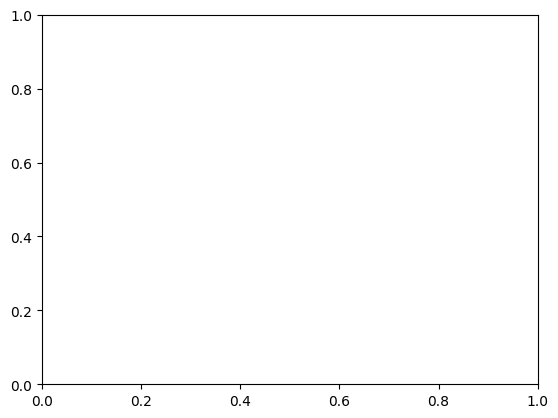

In [255]:
Tms = np.sort(np.array(analysis_df["Tm"]))
Tms.shape

index = np.arange(0,902,1)

plt.scatter(index, Tms)

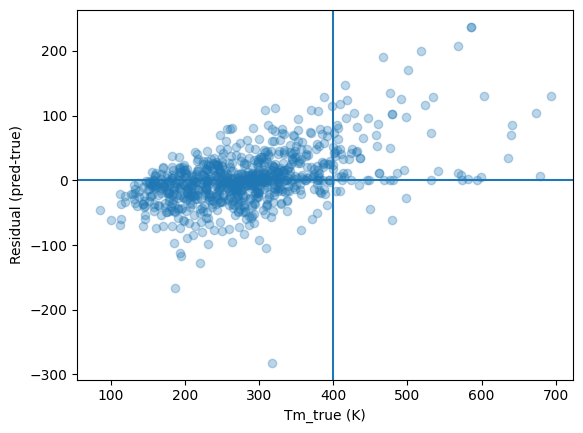

In [274]:
import matplotlib.pyplot as plt
res = (analysis_df["Tm"] - analysis_df["Tm_pred"])



plt.scatter(analysis_df["Tm"], res, alpha=0.3)
plt.axhline(0)
plt.axvline(400)
plt.xlabel("Tm_true (K)")
plt.ylabel("Residual (pred-true)")
plt.show()



In [ ]:
df[df["Tm"] > 0]

,SMILES,Tm,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,FC1=C(F)C(F)(F)C1(F)F,213.15,11.537037,11.537037,2.668981,-4.947338,0.479530,28.200000,162.032,162.032,...,0,0,0,0,0,0,0,0,1,0
1,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,3.470111,3.470111,1.207271,1.207271,0.446879,11.529412,217.271,206.183,...,0,0,0,0,1,1,1,0,1,0
2,CCN1C(C)=Nc2ccccc12,324.15,4.446898,4.446898,0.992407,0.992407,0.625839,10.833333,160.220,148.124,...,0,1,0,1,1,1,1,0,1,0
3,CC#CC(=O)O,351.15,9.425694,9.425694,1.071759,-1.071759,0.422302,5.500000,84.074,80.042,...,1,0,1,1,0,0,0,1,0,0
4,CCCCC(S)C,126.15,4.232083,4.232083,0.597176,0.597176,0.540734,14.142857,118.245,104.133,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2821,CC(C)NCC(COC1=CC=CC=C1CC=C)O,380.15,9.772509,9.772509,0.299480,-0.496123,0.693681,12.444444,249.354,226.170,...,1,1,1,1,1,1,1,1,1,0
2822,CN(C)C1=NC(=NC(=N1)N(C)C)N(C)C,445.15,4.317778,4.317778,0.664259,0.664259,0.703380,10.000000,210.285,192.141,...,0,1,0,1,1,1,1,0,1,0
2823,C1C2CC3CC1CC(C2)(C3)N,433.15,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,134.117,...,0,1,0,0,1,0,1,0,1,0
2824,CC[N+](CC)(CCNC(=O)C(=O)NCC[N+](CC)(CC)CC1=CC=...,469.15,12.474516,12.474516,0.425409,-0.587731,0.272662,11.833333,537.576,495.240,...,0,1,1,1,1,1,1,1,1,0


In [281]:
dev = np.abs(np.array(analysis_df["Tm"] - analysis_df["Tm_pred"]))

analysis_df["deviation"] = dev

In [296]:
np.mean(np.array(analysis_df["deviation"][analysis_df["Tm"] > 400]))

np.float64(61.1634530416349)